# Modelo de Previsão de Tickets Totais

### Objetivo

Desenvolver um modelo de previsão para a quantidade total de tickets, utilizando dados históricos e métricas relevantes.
O modelo deve ser capaz de prever a demanda futura de tickets mensal, auxiliando na alocação de recursos e planejamento operacional.

### Passos do Projeto

1. **Análise Exploratória de Dados (EDA)**: Compreender a distribuição dos dados, identificar padrões sazonais e tendências.
2. **Pré-processamento de Dados**: Limpeza dos dados, tratamento de valores ausentes e transformação de variáveis.
3. **Seleção de Modelos**: Avaliar diferentes algoritmos de previsão, como ARIMA, Prophet, LSTM, entre outros.
4. **Treinamento e Validação**: Treinar os modelos selecionados e validar seu desempenho utilizando métricas como MAE, RMSE

In [37]:
import sys
import os
import warnings

import pandas as pd
import numpy as np
import mlflow

# imports modelos
from prophet import Prophet
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

warnings.filterwarnings("ignore")
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.insert(0, project_root)

In [38]:
from src.utils.extract_data import get_data

In [39]:
mlflow.set_tracking_uri("https://visiondata.ininetech.com.br/mlflow")
mlflow.set_experiment("run_tickets_totais")
mlflow.autolog(disable=True)

## Extração de dados

In [40]:
df = get_data("../../sql/all_dates2.sql")

## Tratamento de dados

In [41]:
# Converter para datetime e definir como índice
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.sort_index()

In [42]:
print(f"Shape dos dados: {df.shape}")
print(f"Período: {df.index.min()} até {df.index.max()}")
print("Informações: ", df.info())
print("\nEstatísticas:")
print(df.describe())

Shape dos dados: (2064, 1)
Período: 2020-01-06 00:00:00 até 2025-08-30 00:00:00
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2064 entries, 2020-01-06 to 2025-08-30
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   QtTickets  2064 non-null   int64
dtypes: int64(1)
memory usage: 32.2 KB
Informações:  None

Estatísticas:
         QtTickets
count  2064.000000
mean     43.953973
std       6.719381
min      21.000000
25%      39.000000
50%      44.000000
75%      49.000000
max      67.000000


## Separação entre treino e teste

In [43]:
train_size = int(len(df) * 0.7)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [44]:
df = df.asfreq("D")  # força frequência diária
df["QtTickets"] = df["QtTickets"].interpolate()  # preencher valores ausentes

## Funções de avaliação

In [45]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, r2, mape

In [46]:
# AR
def run_ar(train, test):
    model = ARIMA(train, order=(1, 0, 0)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# MA
def run_ma(train, test):
    model = ARIMA(train, order=(0, 0, 1)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# ARMA
def run_arma(train, test):
    model = ARIMA(train, order=(2, 0, 2)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# ARIMA
def run_arima(train, test):
    model = ARIMA(train, order=(2, 1, 2)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# SARIMA
def run_sarima(train, test):
    model = SARIMAX(train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# SARIMAX
def run_sarimax(train, test, exog_train=None, exog_test=None):
    model = SARIMAX(
        train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12), exog=exog_train
    ).fit()
    preds = model.forecast(steps=len(test), exog=exog_test)
    return model, preds


# Holt-Winters
def run_holt_winters(train, test):
    model = ExponentialSmoothing(
        train, trend="add", seasonal="add", seasonal_periods=12
    ).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# Prophet
def run_prophet(train, test):
    prophet_df = train.reset_index().rename(columns={"Date": "ds", "QtTickets": "y"})
    model = Prophet()
    model.fit(prophet_df)
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)
    preds = forecast.set_index("ds")["yhat"][-len(test) :]
    return model, preds


# LightGBM
def run_lightgbm(train, test):
    lgbm = LGBMRegressor(n_estimators=1000)
    lgbm.fit(np.arange(len(train)).reshape(-1, 1), train.values)
    preds = lgbm.predict(np.arange(len(train), len(train) + len(test)).reshape(-1, 1))
    return lgbm, preds

In [47]:
# dicionario de modelos
model = {
    "AR": run_ar,
    "MA": run_ma,
    "ARMA": run_arma,
    "ARIMA": run_arima,
    "SARIMA": run_sarima,
    "SARIMAX": run_sarimax,
    "Holt-Winters": run_holt_winters,
    "Prophet": run_prophet,
    "LightGBM": run_lightgbm,
}

In [51]:
test

,QtTickets
Date,
2023-12-20,33
2023-12-21,53
2023-12-22,41
2023-12-23,52
2023-12-24,40
...,...
2025-08-26,38
2025-08-27,44
2025-08-28,47


In [48]:
# treinar e avaliar cada modelo
list_metrics = {}  # dicionário para armazenar as métricas de cada modelo

for name, func in model.items():
    with mlflow.start_run(run_name=name):
        # treinamento e previsão
        model_fit, preds = func(train["QtTickets"], test["QtTickets"])

        # metricas avaliação
        mae, rmse, r2, mape = evaluate_model(test["QtTickets"], preds)

        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)
        mlflow.log_metric("MAPE", mape)

        # armazenar métricas no dicionário
        list_metrics[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

        # parametros de treino
        mlflow.log_param("Train Size", len(train))
        mlflow.log_param("Test Size", len(test))

        # salvar previsoes como artefato .csv e .pkl
        result_df = pd.DataFrame({"Real": test["QtTickets"], "Previsto": preds})
        csv_path = f"../../../data/{name}_predicoes.csv"
        result_df.to_csv(csv_path, index=False)
        model_fit_path = f"../../../models/{name}_model.pkl"
        pd.to_pickle(model_fit, model_fit_path)

🏃 View run AR at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/cba97e5f82584084a85cf0a3f4537a8e
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run MA at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/38f1e6447b9b464abeb410e1a695746c
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run ARMA at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/464e39ce0bdc4e46b2ad873ff4e42b11
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run ARIMA at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/fb7fbc67059545feb940e971655e2ed7
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run SARIMA at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/eddee4e113fe464faaa3ac750179cde1
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run 

23:40:58 - cmdstanpy - INFO - Chain [1] start processing
23:40:58 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Holt-Winters at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/02643c06384644e7936c986b6ceab636
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run Prophet at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/0d6eb070cf7e4793b06fd6be666bb8d3
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 1444, number of used features: 1
[LightGBM] [Info] Start training from score 43.828255
🏃 View run LightGBM at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/af1e2b996abe4386bd7e2967fe27c957
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1


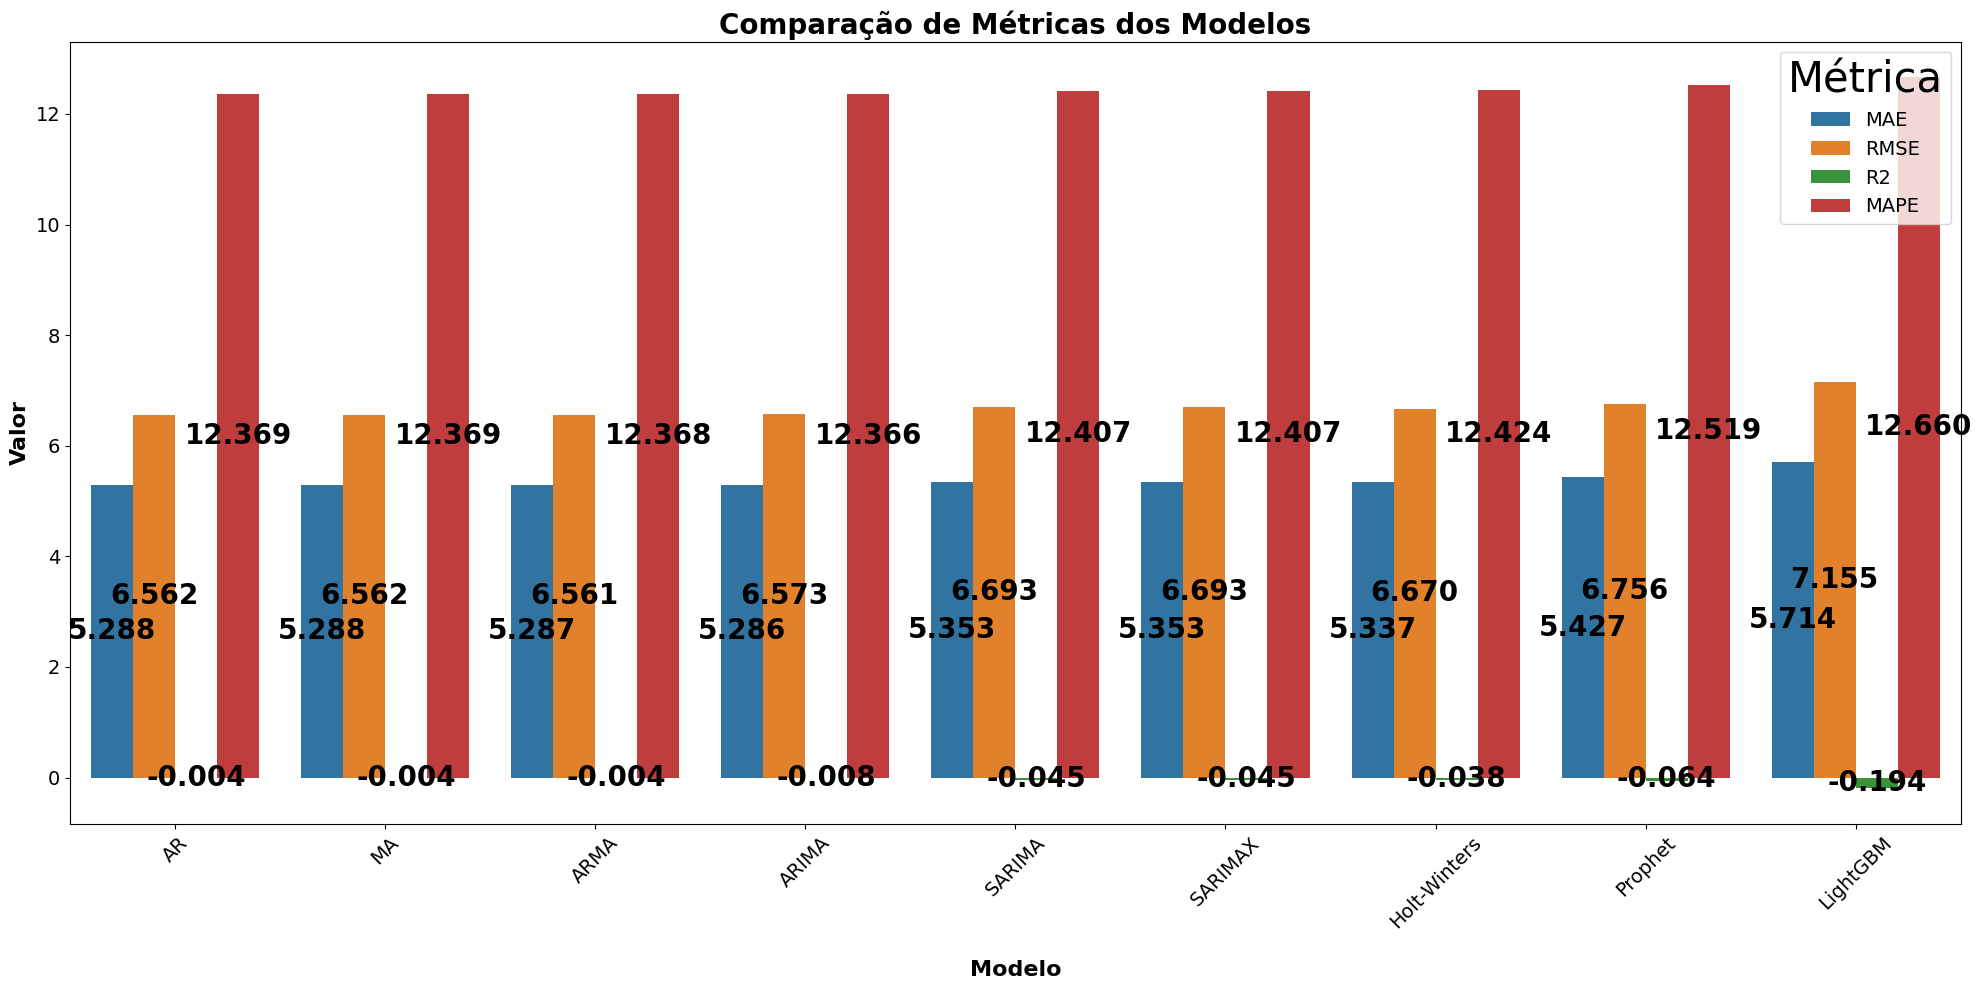

In [49]:
# visualizar métricas de todos os modelos por grafico
import matplotlib.pyplot as plt
import seaborn as sns

metrics_df = pd.DataFrame(list_metrics).T
metrics_df = metrics_df.reset_index().melt(
    id_vars="index", var_name="Métrica", value_name="Valor"
)

plt.figure(figsize=(20, 10))
ax = sns.barplot(data=metrics_df, x="index", y="Valor", hue="Métrica")

# Adicionar valores nas barras com maior destaque
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        label_type="center",
        fontsize=20,
        color="black",
        weight="bold",
    )

plt.title("Comparação de Métricas dos Modelos", fontsize=20, weight="bold")
plt.xlabel("Modelo", fontsize=16, weight="bold", labelpad=20)
plt.ylabel("Valor", fontsize=16, weight="bold")
plt.legend(title="Métrica", fontsize=14, title_fontsize=30)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()